In [ ]:
# ============================================================
# BLOCO 1 - Instalação e importação das bibliotecas
# ============================================================

!pip install -q kaggle tensorflow scikit-learn matplotlib seaborn opencv-python

import os
import glob
import shutil
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# BLOCO 2 - Montar Google Drive e definir caminhos
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Caminho onde o dataset já está salvo no Google Drive
BASE_DIR = "/content/drive/MyDrive/tech_challenge_cbis_ddsm"

# Pasta do projeto para salvar metadata, modelos e resultados
PROJECT_DIR = "/content/drive/MyDrive/tech_challenge_cnn_mamografia"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
REPORT_DIR = os.path.join(PROJECT_DIR, "reports")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("Dataset existe:", os.path.exists(BASE_DIR))
print("PROJECT_DIR:", PROJECT_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("REPORT_DIR:", REPORT_DIR)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/tech_challenge_cbis_ddsm
Dataset existe: True
PROJECT_DIR: /content/drive/MyDrive/tech_challenge_cnn_mamografia
MODEL_DIR: /content/drive/MyDrive/tech_challenge_cnn_mamografia/models
REPORT_DIR: /content/drive/MyDrive/tech_challenge_cnn_mamografia/reports


In [ ]:
# ============================================================
# BLOCO 3 - Validar dataset salvo no Google Drive
# ============================================================

csv_files = glob.glob(BASE_DIR + "/**/*.csv", recursive=True)

image_files = (
    glob.glob(BASE_DIR + "/**/*.jpg", recursive=True) +
    glob.glob(BASE_DIR + "/**/*.png", recursive=True) +
    glob.glob(BASE_DIR + "/**/*.jpeg", recursive=True)
)

print("Quantidade de CSVs encontrados:", len(csv_files))
print("Quantidade de imagens encontradas:", len(image_files))

print("\nArquivos CSV:")
for f in csv_files:
    print(f)

print("\nExemplo de imagens:")
for f in image_files[:10]:
    print(f)

Quantidade de CSVs encontrados: 6
Quantidade de imagens encontradas: 10237

Arquivos CSV:
/content/drive/MyDrive/tech_challenge_cbis_ddsm/csv/calc_case_description_train_set.csv
/content/drive/MyDrive/tech_challenge_cbis_ddsm/csv/mass_case_description_train_set.csv
/content/drive/MyDrive/tech_challenge_cbis_ddsm/csv/meta.csv
/content/drive/MyDrive/tech_challenge_cbis_ddsm/csv/dicom_info.csv
/content/drive/MyDrive/tech_challenge_cbis_ddsm/csv/calc_case_description_test_set.csv
/content/drive/MyDrive/tech_challenge_cbis_ddsm/csv/mass_case_description_test_set.csv

Exemplo de imagens:
/content/drive/MyDrive/tech_challenge_cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.427923087813054053000399778973605332823/1-241.jpg
/content/drive/MyDrive/tech_challenge_cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.427923087813054053000399778973605332823/2-093.jpg
/content/drive/MyDrive/tech_challenge_cbis_ddsm/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/1-296.jpg
/content/drive/MyDrive/tech

In [ ]:
# ============================================================
# BLOCO 4 - Carregar os CSVs clínicos
# ============================================================

def localizar_csv(nome_arquivo):
    encontrados = [
        f for f in csv_files
        if os.path.basename(f) == nome_arquivo
    ]
    if not encontrados:
        raise FileNotFoundError(f"Arquivo não encontrado: {nome_arquivo}")
    return encontrados[0]

mass_train_path = localizar_csv("mass_case_description_train_set.csv")
mass_test_path  = localizar_csv("mass_case_description_test_set.csv")
calc_train_path = localizar_csv("calc_case_description_train_set.csv")
calc_test_path  = localizar_csv("calc_case_description_test_set.csv")

mass_train = pd.read_csv(mass_train_path)
mass_test  = pd.read_csv(mass_test_path)
calc_train = pd.read_csv(calc_train_path)
calc_test  = pd.read_csv(calc_test_path)

mass_train["tipo_lesao"] = "massa"
mass_test["tipo_lesao"] = "massa"
calc_train["tipo_lesao"] = "calcificacao"
calc_test["tipo_lesao"] = "calcificacao"

mass_train["origem_base"] = "train"
mass_test["origem_base"] = "test"
calc_train["origem_base"] = "train"
calc_test["origem_base"] = "test"

df = pd.concat(
    [mass_train, mass_test, calc_train, calc_test],
    ignore_index=True
)

print("Base consolidada:", df.shape)
display(df.head())

print("\nColunas disponíveis:")
print(df.columns.tolist())

Base consolidada: (3568, 19)


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,tipo_lesao,origem_base,breast density,calc type,calc distribution
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,massa,train,NaN,NaN,NaN
1,P_00001,3.0,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,massa,train,NaN,NaN,NaN
2,P_00004,3.0,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,massa,train,NaN,NaN,NaN
3,P_00004,3.0,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,massa,train,NaN,NaN,NaN
4,P_00004,3.0,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,massa,train,NaN,NaN,NaN



Colunas disponíveis:
['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path', 'tipo_lesao', 'origem_base', 'breast density', 'calc type', 'calc distribution']


In [ ]:
# ============================================================
# BLOCO 5 - Criar variável alvo benigno/maligno
# ============================================================

df["pathology"] = df["pathology"].astype(str).str.upper().str.strip()

df["target"] = df["pathology"].map({
    "BENIGN": 0,
    "BENIGN_WITHOUT_CALLBACK": 0,
    "MALIGNANT": 1
})

df = df.dropna(subset=["target"]).copy()
df["target"] = df["target"].astype(int)

print("Distribuição da variável alvo:")
print(df["target"].value_counts())

print("\nDistribuição percentual:")
print((df["target"].value_counts(normalize=True) * 100).round(2))

display(df[["patient_id", "pathology", "target", "tipo_lesao", "origem_base"]].head())

Distribuição da variável alvo:
target
0    2111
1    1457
Name: count, dtype: int64

Distribuição percentual:
target
0    59.16
1    40.84
Name: proportion, dtype: float64


,patient_id,pathology,target,tipo_lesao,origem_base
0,P_00001,MALIGNANT,1,massa,train
1,P_00001,MALIGNANT,1,massa,train
2,P_00004,BENIGN,0,massa,train
3,P_00004,BENIGN,0,massa,train
4,P_00004,BENIGN,0,massa,train


In [ ]:
# ============================================================
# BLOCO 6 - Associar imagens aos diagnósticos
# Versão corrigida e mais robusta
# ============================================================

import os
import re
import glob
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Carrega o dicom_info.csv
# ------------------------------------------------------------

dicom_path = localizar_csv("dicom_info.csv")
dicom_info = pd.read_csv(dicom_path)

print("dicom_info:", dicom_info.shape)
print("\nColunas do dicom_info:")
print(dicom_info.columns.tolist())

display(dicom_info.head())


# ------------------------------------------------------------
# 2. Garante lista de imagens locais
# ------------------------------------------------------------

JPEG_DIR = os.path.join(BASE_DIR, "jpeg")

if "image_files" not in globals() or len(image_files) == 0:
    print("Buscando imagens na pasta JPEG...")
    image_files = (
        glob.glob(os.path.join(JPEG_DIR, "**", "*.jpg"), recursive=True) +
        glob.glob(os.path.join(JPEG_DIR, "**", "*.jpeg"), recursive=True) +
        glob.glob(os.path.join(JPEG_DIR, "**", "*.png"), recursive=True)
    )

print("\nTotal de imagens locais:", len(image_files))


# ------------------------------------------------------------
# 3. Funções auxiliares
# ------------------------------------------------------------

uid_regex = re.compile(r"1\.3\.6(?:\.\d+)+")

def normalizar_path(path):
    if pd.isna(path):
        return None

    path = str(path).replace("\\", "/").strip()
    path = path.replace("./", "")
    path = path.replace("CBIS-DDSM/", "")

    while "//" in path:
        path = path.replace("//", "/")

    return path


def extrair_uids(path):
    if pd.isna(path):
        return []
    return uid_regex.findall(str(path))


# Cria índice UID -> imagem local
uid_para_imagem = {}

for img_path in image_files:
    uids = extrair_uids(img_path)
    for uid in uids:
        if uid not in uid_para_imagem:
            uid_para_imagem[uid] = img_path

print("UIDs indexados a partir das imagens:", len(uid_para_imagem))


def resolver_imagem_local(path):
    """
    Tenta resolver um caminho para imagem local usando:
    1. caminho direto com jpeg/
    2. UID presente no caminho
    """
    if pd.isna(path):
        return None

    path_norm = normalizar_path(path)

    # Tentativa 1: se o caminho já tiver jpeg/
    if "jpeg/" in path_norm:
        parte = path_norm[path_norm.find("jpeg/"):]
        candidato = os.path.join(BASE_DIR, parte)

        if os.path.exists(candidato):
            return candidato

    # Tentativa 2: procurar por UID
    uids = extrair_uids(path_norm)

    # Usa os UIDs de trás para frente, geralmente o último é o mais específico
    for uid in reversed(uids):
        if uid in uid_para_imagem:
            return uid_para_imagem[uid]

    return None


# ------------------------------------------------------------
# 4. Identifica colunas úteis no dicom_info
# ------------------------------------------------------------

colunas_texto = dicom_info.select_dtypes(include=["object"]).columns.tolist()

colunas_com_dcm = []
colunas_com_jpg = []

for col in colunas_texto:
    serie = dicom_info[col].astype(str)

    if serie.str.contains(".dcm", case=False, regex=False).any():
        colunas_com_dcm.append(col)

    if serie.str.contains(".jpg", case=False, regex=False).any() or serie.str.contains("jpeg", case=False, regex=False).any():
        colunas_com_jpg.append(col)

print("\nColunas com DICOM:")
print(colunas_com_dcm)

print("\nColunas com JPG/JPEG:")
print(colunas_com_jpg)

# Define colunas principais
file_path_col = "file_path" if "file_path" in dicom_info.columns else colunas_com_dcm[0]
image_path_col = "image_path" if "image_path" in dicom_info.columns else colunas_com_jpg[0]

print("\nColuna DICOM usada:", file_path_col)
print("Coluna imagem usada:", image_path_col)


# ------------------------------------------------------------
# 5. Resolve imagem local no dicom_info
# ------------------------------------------------------------

dicom_info["local_image_path"] = dicom_info[image_path_col].apply(resolver_imagem_local)

print("\nImagens resolvidas no dicom_info:")
print(dicom_info["local_image_path"].notna().sum(), "de", len(dicom_info))

display(dicom_info[[file_path_col, image_path_col, "local_image_path"]].head())


# ------------------------------------------------------------
# 6. Cria mapa DICOM -> JPG local
# ------------------------------------------------------------

mapa_dicom_para_jpg = {}

for _, row in dicom_info.iterrows():
    origem = row[file_path_col]
    destino = row["local_image_path"]

    if pd.isna(destino):
        continue

    origem_norm = normalizar_path(origem)

    if origem_norm:
        mapa_dicom_para_jpg[origem_norm] = destino

        partes = origem_norm.split("/")

        # Também cria chaves por sufixos do caminho
        for n in [6, 5, 4, 3, 2]:
            if len(partes) >= n:
                chave = "/".join(partes[-n:])
                mapa_dicom_para_jpg[chave] = destino

        # Também cria chaves por UID
        uids = extrair_uids(origem_norm)
        for uid in uids:
            mapa_dicom_para_jpg[uid] = destino

print("\nTotal de chaves no mapa DICOM -> JPG:", len(mapa_dicom_para_jpg))


def buscar_imagem_por_csv(path_csv):
    if pd.isna(path_csv):
        return None

    path_norm = normalizar_path(path_csv)

    # Tentativa 1: caminho completo
    if path_norm in mapa_dicom_para_jpg:
        return mapa_dicom_para_jpg[path_norm]

    # Tentativa 2: sufixos do caminho
    partes = path_norm.split("/")

    for n in [6, 5, 4, 3, 2]:
        if len(partes) >= n:
            chave = "/".join(partes[-n:])
            if chave in mapa_dicom_para_jpg:
                return mapa_dicom_para_jpg[chave]

    # Tentativa 3: UID
    uids = extrair_uids(path_norm)

    for uid in reversed(uids):
        if uid in mapa_dicom_para_jpg:
            return mapa_dicom_para_jpg[uid]

        if uid in uid_para_imagem:
            return uid_para_imagem[uid]

    return None


# ------------------------------------------------------------
# 7. Testa as colunas de imagem do CSV clínico
# ------------------------------------------------------------

colunas_imagem_clinica = [
    "cropped image file path",
    "image file path",
    "ROI mask file path"
]

resultados_mapeamento = {}

for col in colunas_imagem_clinica:
    if col in df.columns:
        nova_coluna = f"local_{col}"
        df[nova_coluna] = df[col].apply(buscar_imagem_por_csv)
        qtd = df[nova_coluna].notna().sum()
        resultados_mapeamento[col] = qtd
        print(f"{col}: {qtd} imagens localizadas")

print("\nResumo do mapeamento:")
print(resultados_mapeamento)


# ------------------------------------------------------------
# 8. Escolhe a melhor coluna para treinamento
# ------------------------------------------------------------

if len(resultados_mapeamento) == 0:
    raise ValueError("Nenhuma coluna de imagem foi encontrada no CSV clínico.")

coluna_escolhida = max(resultados_mapeamento, key=resultados_mapeamento.get)

df["image_path_local"] = df[f"local_{coluna_escolhida}"]

print("\nColuna escolhida para treinamento:", coluna_escolhida)
print("Total de registros:", len(df))
print("Imagens localizadas:", df["image_path_local"].notna().sum())
print("Imagens não localizadas:", df["image_path_local"].isna().sum())

display(df[[coluna_escolhida, "image_path_local", "pathology", "target", "tipo_lesao"]].head(10))

dicom_info: (10237, 38)

Colunas do dicom_info:
['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestImagePixelValue', 'SpecificCharacterSet', 'StudyDate', 'StudyID', 'StudyInstanceUID', 'StudyTime']


,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN



Total de imagens locais: 10237
UIDs indexados a partir das imagens: 6774

Colunas com DICOM:
['file_path', 'PatientID']

Colunas com JPG/JPEG:
['image_path']

Coluna DICOM usada: file_path
Coluna imagem usada: image_path

Imagens resolvidas no dicom_info:
10237 de 10237


,file_path,image_path,local_image_path
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,/content/drive/MyDrive/tech_challenge_cbis_dds...
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,/content/drive/MyDrive/tech_challenge_cbis_dds...
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,/content/drive/MyDrive/tech_challenge_cbis_dds...
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,/content/drive/MyDrive/tech_challenge_cbis_dds...
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,/content/drive/MyDrive/tech_challenge_cbis_dds...



Total de chaves no mapa DICOM -> JPG: 27248
cropped image file path: 3567 imagens localizadas
image file path: 3568 imagens localizadas
ROI mask file path: 3567 imagens localizadas

Resumo do mapeamento:
{'cropped image file path': np.int64(3567), 'image file path': np.int64(3568), 'ROI mask file path': np.int64(3567)}

Coluna escolhida para treinamento: image file path
Total de registros: 3568
Imagens localizadas: 3568
Imagens não localizadas: 0


,image file path,image_path_local,pathology,target,tipo_lesao
0,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,/content/drive/MyDrive/tech_challenge_cbis_dds...,MALIGNANT,1,massa
1,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,/content/drive/MyDrive/tech_challenge_cbis_dds...,MALIGNANT,1,massa
2,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,/content/drive/MyDrive/tech_challenge_cbis_dds...,BENIGN,0,massa
3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,/content/drive/MyDrive/tech_challenge_cbis_dds...,BENIGN,0,massa
4,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,/content/drive/MyDrive/tech_challenge_cbis_dds...,BENIGN,0,massa
5,Mass-Training_P_00009_RIGHT_CC/1.3.6.1.4.1.959...,/content/drive/MyDrive/tech_challenge_cbis_dds...,MALIGNANT,1,massa
6,Mass-Training_P_00009_RIGHT_MLO/1.3.6.1.4.1.95...,/content/drive/MyDrive/tech_challenge_cbis_dds...,MALIGNANT,1,massa
7,Mass-Training_P_00015_LEFT_MLO/1.3.6.1.4.1.959...,/content/drive/MyDrive/tech_challenge_cbis_dds...,MALIGNANT,1,massa
8,Mass-Training_P_00018_RIGHT_CC/1.3.6.1.4.1.959...,/content/drive/MyDrive/tech_challenge_cbis_dds...,BENIGN,0,massa
9,Mass-Training_P_00018_RIGHT_MLO/1.3.6.1.4.1.95...,/content/drive/MyDrive/tech_challenge_cbis_dds...,BENIGN,0,massa


In [ ]:
# ============================================================
# BLOCO 7 - Criar base final para treinamento da CNN
# ============================================================

df_img = df[df["image_path_local"].notna()].copy()

df_img = df_img[
    [
        "patient_id",
        "pathology",
        "target",
        "tipo_lesao",
        "origem_base",
        "image_path_local"
    ]
].copy()

print("Base final para CNN:", df_img.shape)

print("\nDistribuição por classe:")
print(df_img["target"].value_counts())

print("\nDistribuição percentual:")
print((df_img["target"].value_counts(normalize=True) * 100).round(2))

print("\nDistribuição por tipo de lesão:")
print(df_img["tipo_lesao"].value_counts())

display(df_img.head())

metadata_path = os.path.join(PROJECT_DIR, "metadata_cnn_mamografia.csv")
df_img.to_csv(metadata_path, index=False)

print("\nMetadata salva em:")
print(metadata_path)

Base final para CNN: (3568, 6)

Distribuição por classe:
target
0    2111
1    1457
Name: count, dtype: int64

Distribuição percentual:
target
0    59.16
1    40.84
Name: proportion, dtype: float64

Distribuição por tipo de lesão:
tipo_lesao
calcificacao    1872
massa           1696
Name: count, dtype: int64


,patient_id,pathology,target,tipo_lesao,origem_base,image_path_local
0,P_00001,MALIGNANT,1,massa,train,/content/drive/MyDrive/tech_challenge_cbis_dds...
1,P_00001,MALIGNANT,1,massa,train,/content/drive/MyDrive/tech_challenge_cbis_dds...
2,P_00004,BENIGN,0,massa,train,/content/drive/MyDrive/tech_challenge_cbis_dds...
3,P_00004,BENIGN,0,massa,train,/content/drive/MyDrive/tech_challenge_cbis_dds...
4,P_00004,BENIGN,0,massa,train,/content/drive/MyDrive/tech_challenge_cbis_dds...



Metadata salva em:
/content/drive/MyDrive/tech_challenge_cnn_mamografia/metadata_cnn_mamografia.csv


In [ ]:
# ============================================================
# BLOCO 8 - Separação em treino, validação e teste
# ============================================================

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_img,
    test_size=0.30,
    random_state=42,
    stratify=df_img["target"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["target"]
)

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)

print("\nDistribuição treino:")
print(train_df["target"].value_counts(normalize=True).round(3))

print("\nDistribuição validação:")
print(val_df["target"].value_counts(normalize=True).round(3))

print("\nDistribuição teste:")
print(test_df["target"].value_counts(normalize=True).round(3))

Treino: (2497, 6)
Validação: (535, 6)
Teste: (536, 6)

Distribuição treino:
target
0    0.592
1    0.408
Name: proportion, dtype: float64

Distribuição validação:
target
0    0.593
1    0.407
Name: proportion, dtype: float64

Distribuição teste:
target
0    0.591
1    0.409
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# BLOCO 9 - Pipeline de imagens para TensorFlow
# ============================================================

import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def carregar_imagem(path, label):
    """
    Lê a imagem do caminho local, converte para RGB,
    redimensiona e retorna imagem + rótulo.
    """
    imagem = tf.io.read_file(path)
    imagem = tf.image.decode_image(imagem, channels=3, expand_animations=False)
    imagem.set_shape([None, None, 3])
    imagem = tf.image.resize(imagem, IMG_SIZE)

    label = tf.cast(label, tf.float32)

    return imagem, label


def criar_dataset(dataframe, shuffle=False):
    caminhos = dataframe["image_path_local"].values
    labels = dataframe["target"].values

    ds = tf.data.Dataset.from_tensor_slices((caminhos, labels))
    ds = ds.map(carregar_imagem, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = criar_dataset(train_df, shuffle=True)
val_ds = criar_dataset(val_df, shuffle=False)
test_ds = criar_dataset(test_df, shuffle=False)

print("Pipeline criado com sucesso.")

# Visualizar um batch
for imagens, labels in train_ds.take(1):
    print("Formato das imagens:", imagens.shape)
    print("Formato dos labels:", labels.shape)
    print("Labels exemplo:", labels[:10].numpy())

Pipeline criado com sucesso.
Formato das imagens: (16, 224, 224, 3)
Formato dos labels: (16,)
Labels exemplo: [0. 0. 0. 0. 1. 1. 1. 1. 0. 1.]


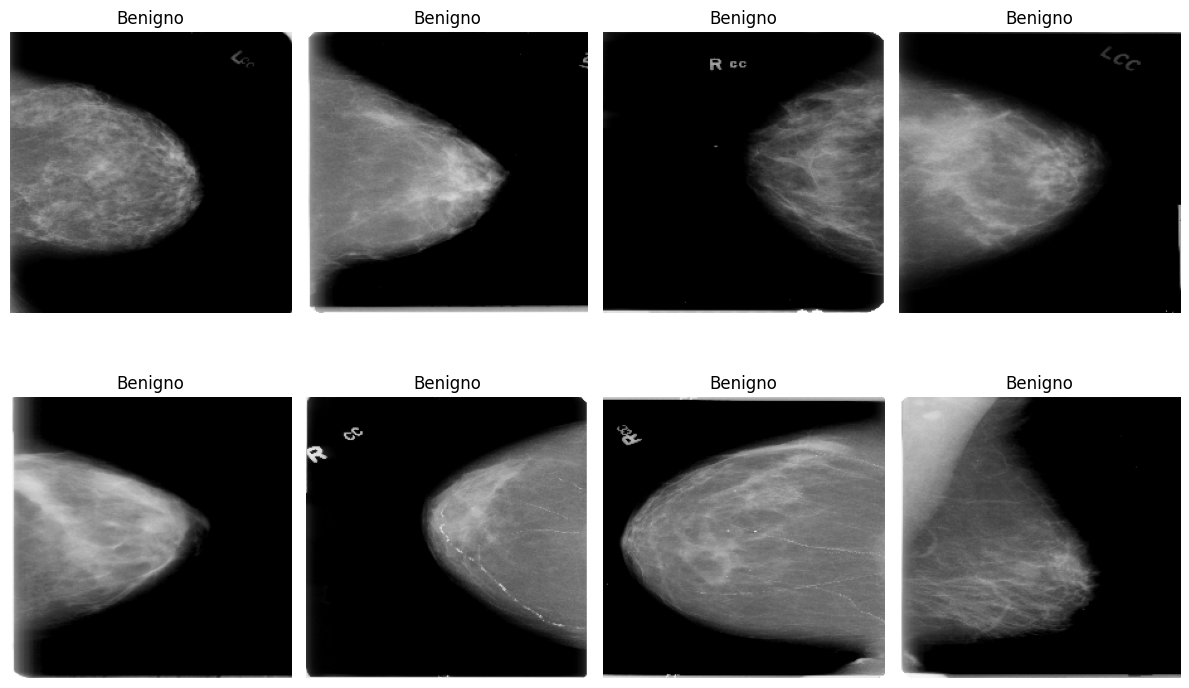

In [ ]:
# ============================================================
# BLOCO 10 - Visualizar exemplos de imagens
# ============================================================

plt.figure(figsize=(12, 8))

for imagens, labels in train_ds.take(1):
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(imagens[i].numpy().astype("uint8"))

        classe = "Maligno" if labels[i].numpy() == 1 else "Benigno"
        plt.title(classe)
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# BLOCO 11 - Cálculo de class_weight
# ============================================================

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

pesos = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["target"].values
)

class_weight = {
    0: pesos[0],
    1: pesos[1]
}

print("Class weights:")
print(class_weight)

Class weights:
{0: np.float64(0.8452945159106297), 1: np.float64(1.2240196078431373)}


In [ ]:
# ============================================================
# BLOCO 12 - Construção da CNN com Transfer Learning
# ============================================================

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models

tf.keras.backend.clear_session()

IMG_SHAPE = IMG_SIZE + (3,)

# Camadas de data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

# Modelo base pré-treinado
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SHAPE
)

# Congela a base inicialmente
base_model.trainable = False

inputs = layers.Input(shape=IMG_SHAPE)

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.30)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
# ============================================================
# BLOCO 13 - Treinamento inicial da CNN
# ============================================================

best_model_path = os.path.join(MODEL_DIR, "best_effnet_cnn_mamografia.keras")

callbacks = [
    EarlyStopping(
        monitor="val_auc",
        patience=5,
        mode="max",
        restore_best_weights=True
    ),
    ModelCheckpoint(
        best_model_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks
)

print("Treinamento finalizado.")
print("Melhor modelo salvo em:", best_model_path)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5235 - auc: 0.5320 - loss: 0.7102 - precision: 0.4298 - recall: 0.5193
Epoch 1: val_auc improved from None to 0.62463, saving model to /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_effnet_cnn_mamografia.keras

Epoch 1: finished saving model to /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_effnet_cnn_mamografia.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 341s 794ms/step - accuracy: 0.5479 - auc: 0.5643 - loss: 0.6966 - precision: 0.4550 - recall: 0.5402 - val_accuracy: 0.5757 - val_auc: 0.6246 - val_loss: 0.6762 - val_precision: 0.4862 - val_recall: 0.7294 - learning_rate: 1.0000e-04
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5589 - auc: 0.6103 - loss: 0.6805 - precision: 0.4907 - recall: 0.6404
Epoch 2: val_auc improved from 0.62463 to 0.65422, saving model to /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_effnet_cnn_mamografia.keras

Epoch 2: finish

,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
10,0.662795,0.727655,0.610530,0.576329,0.658824,0.624299,0.693731,0.643060,0.529412,0.701835,0.000030
11,0.645174,0.704836,0.626000,0.558059,0.631373,0.620561,0.694563,0.642482,0.525597,0.706422,0.000030
12,0.651181,0.713990,0.619078,0.560324,0.678431,0.616822,0.694838,0.643277,0.522184,0.701835,0.000030
13,0.664397,0.724584,0.611941,0.573984,0.692157,0.620561,0.695468,0.642619,0.525773,0.701835,0.000009
14,0.647177,0.712866,0.619136,0.557296,0.662745,0.633645,0.696191,0.639360,0.538732,0.701835,0.000009


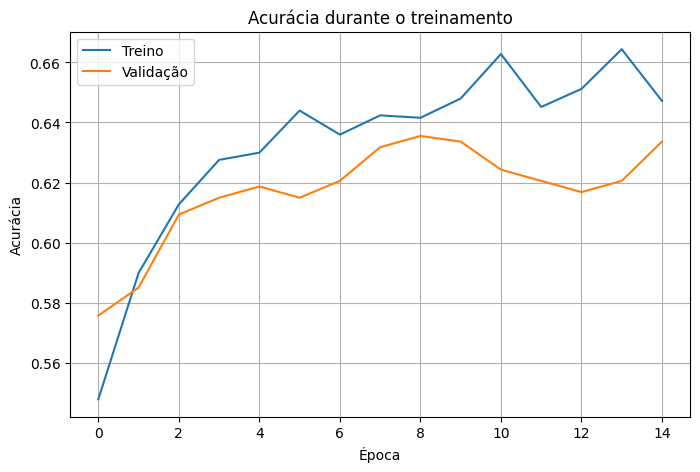

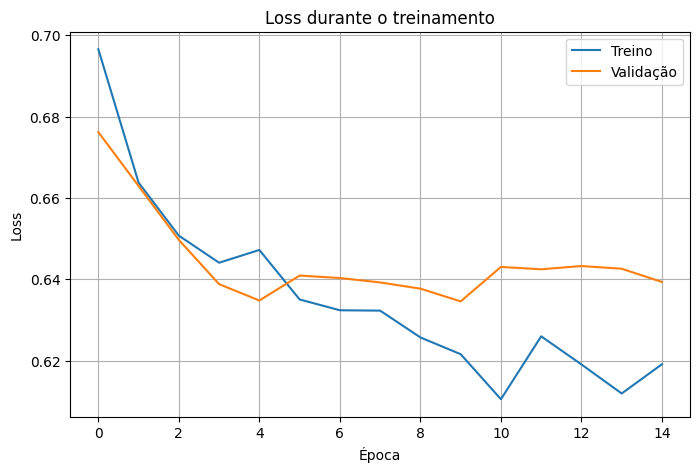

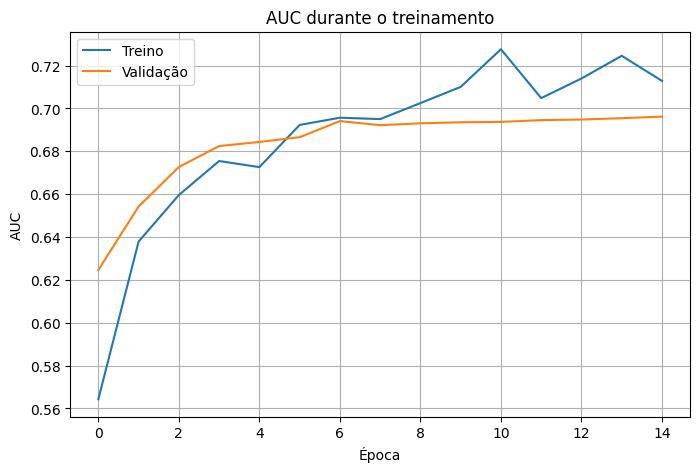

In [ ]:
# ============================================================
# BLOCO 14 - Gráficos de treinamento
# ============================================================

history_df = pd.DataFrame(history.history)
display(history_df.tail())

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_df["accuracy"], label="Treino")
plt.plot(history_df["val_accuracy"], label="Validação")
plt.title("Acurácia durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Treino")
plt.plot(history_df["val_loss"], label="Validação")
plt.title("Loss durante o treinamento")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# AUC
plt.figure(figsize=(8, 5))
plt.plot(history_df["auc"], label="Treino")
plt.plot(history_df["val_auc"], label="Validação")
plt.title("AUC durante o treinamento")
plt.xlabel("Época")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# BLOCO 15 - Avaliação no conjunto de teste
# ============================================================

# Carrega melhor modelo salvo
best_model = tf.keras.models.load_model(best_model_path)

# Probabilidades
y_prob = best_model.predict(test_ds).ravel()

# Classe final usando threshold padrão de 0.5
y_pred = (y_prob >= 0.5).astype(int)

y_true = test_df["target"].values

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_prob)

print("Métricas no teste:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {auc_score:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Benigno", "Maligno"]
))

34/34 ━━━━━━━━━━━━━━━━━━━━ 129s 4s/step
Métricas no teste:
Accuracy:  0.6399
Precision: 0.5474
Recall:    0.6849
F1-score:  0.6085
ROC-AUC:   0.6918

Classification Report:
              precision    recall  f1-score   support

     Benigno       0.74      0.61      0.67       317
     Maligno       0.55      0.68      0.61       219

    accuracy                           0.64       536
   macro avg       0.64      0.65      0.64       536
weighted avg       0.66      0.64      0.64       536



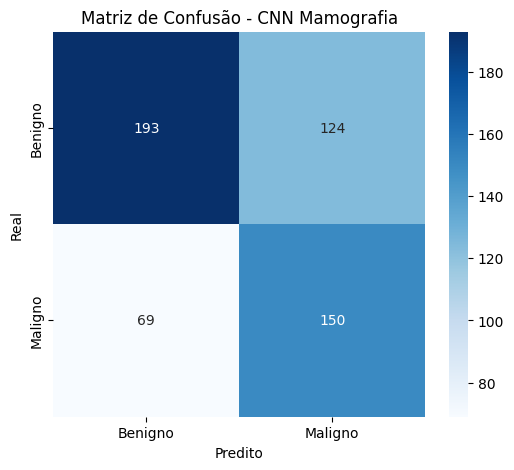

In [ ]:
# ============================================================
# BLOCO 16 - Matriz de confusão
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"]
)

plt.title("Matriz de Confusão - CNN Mamografia")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

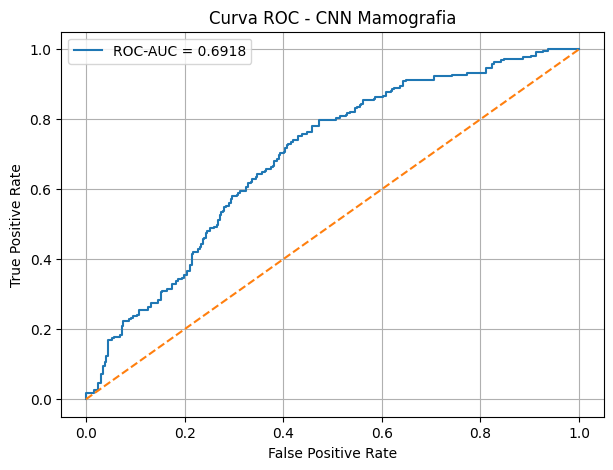

In [ ]:
# ============================================================
# BLOCO 17 - Curva ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("Curva ROC - CNN Mamografia")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# SALVAR SPLITS PARA RETOMAR AMANHÃ
# ============================================================

splits_dir = os.path.join(PROJECT_DIR, "splits")
os.makedirs(splits_dir, exist_ok=True)

train_df.to_csv(os.path.join(splits_dir, "train_df.csv"), index=False)
val_df.to_csv(os.path.join(splits_dir, "val_df.csv"), index=False)
test_df.to_csv(os.path.join(splits_dir, "test_df.csv"), index=False)

print("Splits salvos em:", splits_dir)
print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)

Splits salvos em: /content/drive/MyDrive/tech_challenge_cnn_mamografia/splits
Treino: (2497, 6)
Validação: (535, 6)
Teste: (536, 6)


In [ ]:
# ============================================================
# SALVAR MÉTRICAS DO MODELO INICIAL
# ============================================================

metricas_iniciais = pd.DataFrame([{
    "modelo": "EfficientNetB0_transfer_learning",
    "threshold": 0.50,
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1,
    "roc_auc": auc_score
}])

metricas_path = os.path.join(REPORT_DIR, "metricas_modelo_inicial.csv")
metricas_iniciais.to_csv(metricas_path, index=False)

print("Métricas salvas em:", metricas_path)
display(metricas_iniciais)

Métricas salvas em: /content/drive/MyDrive/tech_challenge_cnn_mamografia/reports/metricas_modelo_inicial.csv


,modelo,threshold,accuracy,precision,recall,f1_score,roc_auc
0,EfficientNetB0_transfer_learning,0.5,0.639925,0.547445,0.684932,0.608519,0.691802


In [ ]:
# ============================================================
# CHECKPOINT FINAL - Conferir arquivos salvos
# ============================================================

arquivos_para_conferir = [
    os.path.join(MODEL_DIR, "best_effnet_cnn_mamografia.keras"),
    os.path.join(PROJECT_DIR, "metadata_cnn_mamografia.csv"),
    os.path.join(PROJECT_DIR, "splits", "train_df.csv"),
    os.path.join(PROJECT_DIR, "splits", "val_df.csv"),
    os.path.join(PROJECT_DIR, "splits", "test_df.csv"),
    os.path.join(REPORT_DIR, "metricas_modelo_inicial.csv")
]

for arquivo in arquivos_para_conferir:
    print(os.path.exists(arquivo), "->", arquivo)

True -> /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_effnet_cnn_mamografia.keras
True -> /content/drive/MyDrive/tech_challenge_cnn_mamografia/metadata_cnn_mamografia.csv
True -> /content/drive/MyDrive/tech_challenge_cnn_mamografia/splits/train_df.csv
True -> /content/drive/MyDrive/tech_challenge_cnn_mamografia/splits/val_df.csv
True -> /content/drive/MyDrive/tech_challenge_cnn_mamografia/splits/test_df.csv
True -> /content/drive/MyDrive/tech_challenge_cnn_mamografia/reports/metricas_modelo_inicial.csv


In [ ]:
# ============================================================
# RETOMADA - Setup do ambiente
# ============================================================

!pip install -q tensorflow scikit-learn matplotlib seaborn opencv-python

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/tech_challenge_cbis_ddsm"
PROJECT_DIR = "/content/drive/MyDrive/tech_challenge_cnn_mamografia"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
REPORT_DIR = os.path.join(PROJECT_DIR, "reports")
SPLITS_DIR = os.path.join(PROJECT_DIR, "splits")

best_model_path = os.path.join(MODEL_DIR, "best_effnet_cnn_mamografia.keras")

train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train_df.csv"))
val_df = pd.read_csv(os.path.join(SPLITS_DIR, "val_df.csv"))
test_df = pd.read_csv(os.path.join(SPLITS_DIR, "test_df.csv"))

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)
print("Modelo inicial existe:", os.path.exists(best_model_path))

Mounted at /content/drive
Treino: (2497, 6)
Validação: (535, 6)
Teste: (536, 6)
Modelo inicial existe: True


In [ ]:
# ============================================================
# BLOCO 22 - Recriar pipeline de imagens
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def carregar_imagem(path, label):
    imagem = tf.io.read_file(path)
    imagem = tf.image.decode_image(imagem, channels=3, expand_animations=False)
    imagem.set_shape([None, None, 3])
    imagem = tf.image.resize(imagem, IMG_SIZE)
    label = tf.cast(label, tf.float32)
    return imagem, label

def criar_dataset(dataframe, shuffle=False):
    caminhos = dataframe["image_path_local"].values
    labels = dataframe["target"].values

    ds = tf.data.Dataset.from_tensor_slices((caminhos, labels))
    ds = ds.map(carregar_imagem, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = criar_dataset(train_df, shuffle=True)
val_ds = criar_dataset(val_df, shuffle=False)
test_ds = criar_dataset(test_df, shuffle=False)

print("Pipeline recriado com sucesso.")

Pipeline recriado com sucesso.


In [ ]:
# ============================================================
# BLOCO 23 - Recalcular class_weight
# ============================================================

classes = np.array([0, 1])

pesos = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["target"].values
)

class_weight = {
    0: pesos[0],
    1: pesos[1]
}

print("Class weights:")
print(class_weight)

Class weights:
{0: np.float64(0.8452945159106297), 1: np.float64(1.2240196078431373)}


In [ ]:
# ============================================================
# BLOCO 24 - Ajuste de threshold usando validação
# ============================================================

best_model = tf.keras.models.load_model(best_model_path)

y_val_prob = best_model.predict(val_ds).ravel()
y_val_true = val_df["target"].values

resultados_threshold = []

for threshold in np.arange(0.10, 0.91, 0.01):
    y_val_pred = (y_val_prob >= threshold).astype(int)

    resultados_threshold.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val_true, y_val_pred),
        "precision": precision_score(y_val_true, y_val_pred, zero_division=0),
        "recall": recall_score(y_val_true, y_val_pred, zero_division=0),
        "f1": f1_score(y_val_true, y_val_pred, zero_division=0)
    })

df_threshold = pd.DataFrame(resultados_threshold)

print("Top 10 thresholds por accuracy:")
display(df_threshold.sort_values("accuracy", ascending=False).head(10))

print("Top 10 thresholds por F1-score:")
display(df_threshold.sort_values("f1", ascending=False).head(10))

# Escolha equilibrada: maior accuracy mantendo recall maligno mínimo de 60%
df_threshold_seguro = df_threshold[df_threshold["recall"] >= 0.60].copy()

if len(df_threshold_seguro) > 0:
    threshold_final = df_threshold_seguro.sort_values("accuracy", ascending=False).iloc[0]["threshold"]
else:
    threshold_final = df_threshold.sort_values("f1", ascending=False).iloc[0]["threshold"]

print("Threshold escolhido:", round(threshold_final, 2))

34/34 ━━━━━━━━━━━━━━━━━━━━ 229s 6s/step
Top 10 thresholds por accuracy:


,threshold,accuracy,precision,recall,f1
52,0.62,0.648598,0.601351,0.408257,0.486339
49,0.59,0.648598,0.585227,0.472477,0.522843
51,0.61,0.644860,0.588608,0.426606,0.494681
48,0.58,0.642991,0.571429,0.495413,0.530713
50,0.60,0.642991,0.581818,0.440367,0.501305
53,0.63,0.642991,0.595745,0.385321,0.467967
63,0.73,0.637383,0.730769,0.174312,0.281481
41,0.51,0.635514,0.542751,0.669725,0.599589
59,0.69,0.635514,0.632184,0.252294,0.360656
58,0.68,0.635514,0.626374,0.261468,0.368932


Top 10 thresholds por F1-score:


,threshold,accuracy,precision,recall,f1
30,0.40,0.594393,0.501266,0.908257,0.646003
32,0.42,0.601869,0.506631,0.876147,0.642017
28,0.38,0.573832,0.487864,0.922018,0.638095
29,0.39,0.577570,0.490148,0.912844,0.637821
31,0.41,0.590654,0.498701,0.880734,0.636816
27,0.37,0.566355,0.483254,0.926606,0.635220
34,0.44,0.609346,0.512748,0.830275,0.633975
33,0.43,0.600000,0.505495,0.844037,0.632302
25,0.35,0.540187,0.468889,0.967890,0.631737
24,0.34,0.532710,0.464912,0.972477,0.629080


Threshold escolhido: 0.51


In [ ]:
# ============================================================
# BLOCO 25 - Avaliação no teste com threshold ajustado
# ============================================================

y_prob = best_model.predict(test_ds).ravel()
y_true = test_df["target"].values

y_pred_threshold = (y_prob >= threshold_final).astype(int)

acc_thr = accuracy_score(y_true, y_pred_threshold)
prec_thr = precision_score(y_true, y_pred_threshold)
rec_thr = recall_score(y_true, y_pred_threshold)
f1_thr = f1_score(y_true, y_pred_threshold)
auc_thr = roc_auc_score(y_true, y_prob)

print("Threshold usado:", round(threshold_final, 2))
print("Métricas no teste com threshold ajustado:")
print(f"Accuracy:  {acc_thr:.4f}")
print(f"Precision: {prec_thr:.4f}")
print(f"Recall:    {rec_thr:.4f}")
print(f"F1-score:  {f1_thr:.4f}")
print(f"ROC-AUC:   {auc_thr:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred_threshold,
    target_names=["Benigno", "Maligno"]
))

34/34 ━━━━━━━━━━━━━━━━━━━━ 150s 4s/step
Threshold usado: 0.51
Métricas no teste com threshold ajustado:
Accuracy:  0.6399
Precision: 0.5489
Recall:    0.6667
F1-score:  0.6021
ROC-AUC:   0.6918

Classification Report:
              precision    recall  f1-score   support

     Benigno       0.73      0.62      0.67       317
     Maligno       0.55      0.67      0.60       219

    accuracy                           0.64       536
   macro avg       0.64      0.64      0.64       536
weighted avg       0.66      0.64      0.64       536



In [ ]:
# ============================================================
# BLOCO 26 - Preparar fine-tuning da EfficientNetB0
# ============================================================

fine_model = tf.keras.models.load_model(best_model_path)

base_effnet = None

for layer in fine_model.layers:
    if "efficientnet" in layer.name.lower():
        base_effnet = layer
        break

if base_effnet is None:
    raise ValueError("Camada EfficientNet não encontrada.")

print("Base encontrada:", base_effnet.name)
print("Total de camadas:", len(base_effnet.layers))

# Descongela a EfficientNet
base_effnet.trainable = True

# Libera apenas os últimos 25% da rede
fine_tune_at = int(len(base_effnet.layers) * 0.75)

for layer in base_effnet.layers[:fine_tune_at]:
    layer.trainable = False

# Mantém BatchNormalization congelada para estabilidade
for layer in base_effnet.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

camadas_treinaveis = sum([layer.trainable for layer in base_effnet.layers])

print("Camadas treináveis na EfficientNet:", camadas_treinaveis, "de", len(base_effnet.layers))

fine_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

fine_model.summary()

Base encontrada: efficientnetb0
Total de camadas: 238
Camadas treináveis na EfficientNet: 47 de 238


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 2,813,377 (10.73 MB)

 Non-trainable params: 1,400,291 (5.34 MB)

In [ ]:
# ============================================================
# BLOCO 27 - Treinamento com fine-tuning
# ============================================================

fine_model_path = os.path.join(MODEL_DIR, "best_effnet_cnn_mamografia_finetuning_accuracy.keras")

callbacks_fine = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        mode="max",
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        fine_model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

history_fine = fine_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks_fine
)

print("Fine-tuning finalizado.")
print("Melhor modelo salvo em:", fine_model_path)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6404 - auc: 0.7042 - loss: 0.6242 - precision: 0.5413 - recall: 0.6328
Epoch 1: val_accuracy improved from None to 0.63364, saving model to /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_effnet_cnn_mamografia_finetuning_accuracy.keras

Epoch 1: finished saving model to /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_effnet_cnn_mamografia_finetuning_accuracy.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 644s 303ms/step - accuracy: 0.6448 - auc: 0.7134 - loss: 0.6187 - precision: 0.5552 - recall: 0.6559 - val_accuracy: 0.6336 - val_auc: 0.6982 - val_loss: 0.6334 - val_precision: 0.5407 - val_recall: 0.6697 - learning_rate: 1.0000e-05
Epoch 2/10
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6481 - auc: 0.7171 - loss: 0.6128 - precision: 0.5554 - recall: 0.6745
Epoch 2: val_accuracy did not improve from 0.63364
157/157 ━━━━━━━━━━━━━━━━━━━━ 229s 313ms/step - accuracy: 0.6648 - auc: 0.7291 - 

In [ ]:
# ============================================================
# BLOCO 28 - Avaliação do modelo com fine-tuning
# ============================================================

final_model = tf.keras.models.load_model(fine_model_path)

y_prob_final = final_model.predict(test_ds).ravel()
y_true = test_df["target"].values

y_pred_final = (y_prob_final >= 0.5).astype(int)

acc_final = accuracy_score(y_true, y_pred_final)
prec_final = precision_score(y_true, y_pred_final)
rec_final = recall_score(y_true, y_pred_final)
f1_final = f1_score(y_true, y_pred_final)
auc_final = roc_auc_score(y_true, y_prob_final)

print("Métricas finais no teste - Fine-tuning:")
print(f"Accuracy:  {acc_final:.4f}")
print(f"Precision: {prec_final:.4f}")
print(f"Recall:    {rec_final:.4f}")
print(f"F1-score:  {f1_final:.4f}")
print(f"ROC-AUC:   {auc_final:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred_final,
    target_names=["Benigno", "Maligno"]
))

34/34 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step
Métricas finais no teste - Fine-tuning:
Accuracy:  0.6455
Precision: 0.5551
Recall:    0.6667
F1-score:  0.6058
ROC-AUC:   0.6948

Classification Report:
              precision    recall  f1-score   support

     Benigno       0.73      0.63      0.68       317
     Maligno       0.56      0.67      0.61       219

    accuracy                           0.65       536
   macro avg       0.64      0.65      0.64       536
weighted avg       0.66      0.65      0.65       536



In [ ]:
# ============================================================
# BLOCO 29 - Comparação dos resultados
# ============================================================

comparacao = pd.DataFrame([
    {
        "modelo": "Inicial - threshold 0.50",
        "accuracy": 0.6399,
        "precision": 0.5474,
        "recall": 0.6849,
        "f1_score": 0.6085,
        "roc_auc": 0.6918
    },
    {
        "modelo": f"Inicial - threshold ajustado {threshold_final:.2f}",
        "accuracy": acc_thr,
        "precision": prec_thr,
        "recall": rec_thr,
        "f1_score": f1_thr,
        "roc_auc": auc_thr
    },
    {
        "modelo": "Fine-tuning - threshold 0.50",
        "accuracy": acc_final,
        "precision": prec_final,
        "recall": rec_final,
        "f1_score": f1_final,
        "roc_auc": auc_final
    }
])

display(comparacao)

comparacao_path = os.path.join(REPORT_DIR, "comparacao_modelos_cnn.csv")
comparacao.to_csv(comparacao_path, index=False)

print("Comparação salva em:", comparacao_path)

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,Inicial - threshold 0.50,0.639900,0.547400,0.684900,0.608500,0.691800
1,Inicial - threshold ajustado 0.51,0.639925,0.548872,0.666667,0.602062,0.691802
2,Fine-tuning - threshold 0.50,0.645522,0.555133,0.666667,0.605809,0.694784


Comparação salva em: /content/drive/MyDrive/tech_challenge_cnn_mamografia/reports/comparacao_modelos_cnn.csv


In [ ]:
# ============================================================
# BLOCO 29.0 - Retomar ambiente e recarregar splits
# ============================================================

import os
import shutil
import pandas as pd
import numpy as np
import tensorflow as tf

from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/tech_challenge_cbis_ddsm"
PROJECT_DIR = "/content/drive/MyDrive/tech_challenge_cnn_mamografia"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
REPORT_DIR = os.path.join(PROJECT_DIR, "reports")
SPLITS_DIR = os.path.join(PROJECT_DIR, "splits")

best_model_path = os.path.join(MODEL_DIR, "best_effnet_cnn_mamografia.keras")

train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train_df.csv"))
val_df = pd.read_csv(os.path.join(SPLITS_DIR, "val_df.csv"))
test_df = pd.read_csv(os.path.join(SPLITS_DIR, "test_df.csv"))

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)
print("Modelo existe:", os.path.exists(best_model_path))
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

Mounted at /content/drive
Treino: (2497, 6)
Validação: (535, 6)
Teste: (536, 6)
Modelo existe: True
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================
# BLOCO 29.1 - Copiar apenas imagens usadas para disco local
# ============================================================

LOCAL_BASE_DIR = "/content/cbis_ddsm_local"

os.makedirs(LOCAL_BASE_DIR, exist_ok=True)

# Junta os três splits para copiar somente imagens utilizadas
df_todas = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Lista única de imagens
imagens_drive = df_todas["image_path_local"].dropna().unique()

print("Total de imagens únicas para copiar:", len(imagens_drive))

copiadas = 0
ja_existiam = 0
erros = 0

for i, caminho_drive in enumerate(imagens_drive, start=1):
    caminho_local = caminho_drive.replace(BASE_DIR, LOCAL_BASE_DIR)

    try:
        os.makedirs(os.path.dirname(caminho_local), exist_ok=True)

        if not os.path.exists(caminho_local):
            shutil.copy2(caminho_drive, caminho_local)
            copiadas += 1
        else:
            ja_existiam += 1

    except Exception as e:
        erros += 1

    if i % 200 == 0:
        print(f"Processadas {i}/{len(imagens_drive)} imagens...")

print("Cópia finalizada.")
print("Copiadas:", copiadas)
print("Já existiam:", ja_existiam)
print("Erros:", erros)

Total de imagens únicas para copiar: 3103
Processadas 200/3103 imagens...
Processadas 400/3103 imagens...
Processadas 600/3103 imagens...
Processadas 800/3103 imagens...
Processadas 1000/3103 imagens...
Processadas 1200/3103 imagens...
Processadas 1400/3103 imagens...
Processadas 1600/3103 imagens...
Processadas 1800/3103 imagens...
Processadas 2000/3103 imagens...
Processadas 2200/3103 imagens...
Processadas 2400/3103 imagens...
Processadas 2600/3103 imagens...
Processadas 2800/3103 imagens...
Processadas 3000/3103 imagens...
Cópia finalizada.
Copiadas: 3103
Já existiam: 0
Erros: 0


In [ ]:
# ============================================================
# BLOCO 29.2 - Atualizar caminhos para usar imagens locais
# ============================================================

def trocar_drive_por_local(df_base):
    df_base = df_base.copy()

    if "image_path_drive" not in df_base.columns:
        df_base["image_path_drive"] = df_base["image_path_local"]

    df_base["image_path_local"] = df_base["image_path_drive"].str.replace(
        BASE_DIR,
        LOCAL_BASE_DIR,
        regex=False
    )

    return df_base

train_df = trocar_drive_por_local(train_df)
val_df = trocar_drive_por_local(val_df)
test_df = trocar_drive_por_local(test_df)

print("Verificando arquivos locais:")

print("Treino local existe:", train_df["image_path_local"].apply(os.path.exists).sum(), "de", len(train_df))
print("Validação local existe:", val_df["image_path_local"].apply(os.path.exists).sum(), "de", len(val_df))
print("Teste local existe:", test_df["image_path_local"].apply(os.path.exists).sum(), "de", len(test_df))

display(train_df.head())

Verificando arquivos locais:
Treino local existe: 2497 de 2497
Validação local existe: 535 de 535
Teste local existe: 536 de 536


,patient_id,pathology,target,tipo_lesao,origem_base,image_path_local,image_path_drive
0,P_00560,BENIGN_WITHOUT_CALLBACK,0,massa,train,/content/cbis_ddsm_local/jpeg/1.3.6.1.4.1.9590...,/content/drive/MyDrive/tech_challenge_cbis_dds...
1,P_01625,MALIGNANT,1,calcificacao,train,/content/cbis_ddsm_local/jpeg/1.3.6.1.4.1.9590...,/content/drive/MyDrive/tech_challenge_cbis_dds...
2,P_00047,MALIGNANT,1,calcificacao,train,/content/cbis_ddsm_local/jpeg/1.3.6.1.4.1.9590...,/content/drive/MyDrive/tech_challenge_cbis_dds...
3,P_00636,MALIGNANT,1,massa,test,/content/cbis_ddsm_local/jpeg/1.3.6.1.4.1.9590...,/content/drive/MyDrive/tech_challenge_cbis_dds...
4,P_00969,MALIGNANT,1,calcificacao,train,/content/cbis_ddsm_local/jpeg/1.3.6.1.4.1.9590...,/content/drive/MyDrive/tech_challenge_cbis_dds...


In [ ]:
# ============================================================
# RETOMADA - Recarregar ambiente e caminhos
# ============================================================

!pip install -q tensorflow scikit-learn matplotlib seaborn opencv-python

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/tech_challenge_cbis_ddsm"
PROJECT_DIR = "/content/drive/MyDrive/tech_challenge_cnn_mamografia"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
REPORT_DIR = os.path.join(PROJECT_DIR, "reports")
SPLITS_DIR = os.path.join(PROJECT_DIR, "splits")

best_model_path = os.path.join(MODEL_DIR, "best_effnet_cnn_mamografia.keras")

train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train_df.csv"))
val_df = pd.read_csv(os.path.join(SPLITS_DIR, "val_df.csv"))
test_df = pd.read_csv(os.path.join(SPLITS_DIR, "test_df.csv"))

print("TensorFlow:", tf.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)
print("Modelo inicial existe:", os.path.exists(best_model_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Treino: (2497, 6)
Validação: (535, 6)
Teste: (536, 6)
Modelo inicial existe: True


In [ ]:
# ============================================================
# BLOCO 29.3 - Recriar pipeline usando imagens locais
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def carregar_imagem(path, label):
    imagem = tf.io.read_file(path)
    imagem = tf.image.decode_jpeg(imagem, channels=3)
    imagem = tf.image.resize(imagem, IMG_SIZE)
    label = tf.cast(label, tf.float32)
    return imagem, label

def criar_dataset(dataframe, shuffle=False):
    caminhos = dataframe["image_path_local"].values
    labels = dataframe["target"].values

    ds = tf.data.Dataset.from_tensor_slices((caminhos, labels))
    ds = ds.map(carregar_imagem, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

train_ds = criar_dataset(train_df, shuffle=True)
val_ds = criar_dataset(val_df, shuffle=False)
test_ds = criar_dataset(test_df, shuffle=False)

print("Pipeline local recriado com sucesso.")

for imagens, labels in train_ds.take(1):
    print("Formato imagens:", imagens.shape)
    print("Formato labels:", labels.shape)

Pipeline local recriado com sucesso.
Formato imagens: (16, 224, 224, 3)
Formato labels: (16,)


In [ ]:
# ============================================================
# BLOCO 30 - Fine-tuning leve sem class_weight
# ============================================================

fine_model_sem_peso = tf.keras.models.load_model(best_model_path)

base_effnet = None

for layer in fine_model_sem_peso.layers:
    if "efficientnet" in layer.name.lower():
        base_effnet = layer
        break

if base_effnet is None:
    raise ValueError("Camada EfficientNet não encontrada.")

print("Base encontrada:", base_effnet.name)
print("Total de camadas:", len(base_effnet.layers))

# Descongela a base
base_effnet.trainable = True

# Libera só os últimos 10% da EfficientNet para ficar mais leve
fine_tune_at = int(len(base_effnet.layers) * 0.90)

for layer in base_effnet.layers[:fine_tune_at]:
    layer.trainable = False

# Mantém BatchNormalization congelada para estabilidade
for layer in base_effnet.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

camadas_treinaveis = sum([layer.trainable for layer in base_effnet.layers])
print("Camadas treináveis na EfficientNet:", camadas_treinaveis, "de", len(base_effnet.layers))

fine_model_sem_peso.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

fine_model_sem_peso_path = os.path.join(
    MODEL_DIR,
    "best_effnet_cnn_mamografia_finetuning_leve_sem_class_weight.keras"
)

callbacks_sem_peso = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        mode="max",
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        fine_model_sem_peso_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

history_sem_peso = fine_model_sem_peso.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks_sem_peso
)

print("Fine-tuning leve sem class_weight finalizado.")
print("Modelo salvo em:", fine_model_sem_peso_path)

Base encontrada: efficientnetb0
Total de camadas: 238
Camadas treináveis na EfficientNet: 19 de 238
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6551 - auc: 0.7117 - loss: 0.6067 - precision: 0.5701 - recall: 0.5194
Epoch 1: val_accuracy improved from None to 0.65234, saving model to /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_effnet_cnn_mamografia_finetuning_leve_sem_class_weight.keras

Epoch 1: finished saving model to /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_effnet_cnn_mamografia_finetuning_leve_sem_class_weight.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 225s 308ms/step - accuracy: 0.6556 - auc: 0.7157 - loss: 0.6052 - precision: 0.5932 - recall: 0.4990 - val_accuracy: 0.6523 - val_auc: 0.7014 - val_loss: 0.6136 - val_precision: 0.5920 - val_recall: 0.4725 - learning_rate: 1.0000e-05
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6602 - auc: 0.7061 - loss: 0.6057 - precision: 0.5895 - recall: 0.4445
Epoch 2

In [2]:
# ============================================================
# RETOMADA PARA RODAR O BLOCO 31
# ============================================================

!pip install -q tensorflow scikit-learn matplotlib seaborn opencv-python

import os
import numpy as np
import pandas as pd
import tensorflow as tf

from google.colab import drive
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

drive.mount('/content/drive')

# Caminhos principais
BASE_DIR = "/content/drive/MyDrive/tech_challenge_cbis_ddsm"
PROJECT_DIR = "/content/drive/MyDrive/tech_challenge_cnn_mamografia"
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
REPORT_DIR = os.path.join(PROJECT_DIR, "reports")
SPLITS_DIR = os.path.join(PROJECT_DIR, "splits")

# Modelo salvo no Bloco 30
fine_model_sem_peso_path = os.path.join(
    MODEL_DIR,
    "best_effnet_cnn_mamografia_finetuning_leve_sem_class_weight.keras"
)

print("Modelo fine-tuning existe:", os.path.exists(fine_model_sem_peso_path))
print("Caminho:", fine_model_sem_peso_path)

# Recarrega splits
train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train_df.csv"))
val_df = pd.read_csv(os.path.join(SPLITS_DIR, "val_df.csv"))
test_df = pd.read_csv(os.path.join(SPLITS_DIR, "test_df.csv"))

print("Treino:", train_df.shape)
print("Validação:", val_df.shape)
print("Teste:", test_df.shape)

print("GPU disponível:", tf.config.list_physical_devices("GPU"))

Mounted at /content/drive
Modelo fine-tuning existe: True
Caminho: /content/drive/MyDrive/tech_challenge_cnn_mamografia/models/best_effnet_cnn_mamografia_finetuning_leve_sem_class_weight.keras
Treino: (2497, 6)
Validação: (535, 6)
Teste: (536, 6)
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ============================================================
# RECRIAR PIPELINE DE TESTE
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def carregar_imagem(path, label):
    imagem = tf.io.read_file(path)
    imagem = tf.image.decode_image(imagem, channels=3, expand_animations=False)
    imagem.set_shape([None, None, 3])
    imagem = tf.image.resize(imagem, IMG_SIZE)
    label = tf.cast(label, tf.float32)
    return imagem, label

def criar_dataset(dataframe, shuffle=False):
    caminhos = dataframe["image_path_local"].values
    labels = dataframe["target"].values

    ds = tf.data.Dataset.from_tensor_slices((caminhos, labels))
    ds = ds.map(carregar_imagem, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)

    return ds

test_ds = criar_dataset(test_df, shuffle=False)

print("Pipeline de teste recriado com sucesso.")

Pipeline de teste recriado com sucesso.


In [5]:
# ============================================================
# BLOCO 31 - Avaliar fine-tuning leve sem class_weight
# ============================================================

modelo_sem_peso = tf.keras.models.load_model(fine_model_sem_peso_path)

y_prob_sem_peso = modelo_sem_peso.predict(test_ds).ravel()
y_true = test_df["target"].values

y_pred_sem_peso = (y_prob_sem_peso >= 0.5).astype(int)

acc_sem_peso = accuracy_score(y_true, y_pred_sem_peso)
prec_sem_peso = precision_score(y_true, y_pred_sem_peso)
rec_sem_peso = recall_score(y_true, y_pred_sem_peso)
f1_sem_peso = f1_score(y_true, y_pred_sem_peso)
auc_sem_peso = roc_auc_score(y_true, y_prob_sem_peso)

print("Métricas finais - Fine-tuning leve sem class_weight:")
print(f"Accuracy:  {acc_sem_peso:.4f}")
print(f"Precision: {prec_sem_peso:.4f}")
print(f"Recall:    {rec_sem_peso:.4f}")
print(f"F1-score:  {f1_sem_peso:.4f}")
print(f"ROC-AUC:   {auc_sem_peso:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred_sem_peso,
    target_names=["Benigno", "Maligno"]
))

34/34 ━━━━━━━━━━━━━━━━━━━━ 372s 10s/step
Métricas finais - Fine-tuning leve sem class_weight:
Accuracy:  0.6399
Precision: 0.5722
Recall:    0.4703
F1-score:  0.5163
ROC-AUC:   0.6929

Classification Report:
              precision    recall  f1-score   support

     Benigno       0.67      0.76      0.71       317
     Maligno       0.57      0.47      0.52       219

    accuracy                           0.64       536
   macro avg       0.62      0.61      0.61       536
weighted avg       0.63      0.64      0.63       536



In [ ]:
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# ============================================================
# BLOCO 32 - Comparação final dos modelos testados
# ============================================================

comparacao_final = pd.DataFrame([
    {
        "modelo": "Inicial - EfficientNetB0 com class_weight",
        "accuracy": 0.6399,
        "precision_maligno": 0.5474,
        "recall_maligno": 0.6849,
        "f1_maligno": 0.6085,
        "roc_auc": 0.6918,
        "decisao": "Melhor opção para triagem"
    },
    {
        "modelo": "Fine-tuning com class_weight",
        "accuracy": 0.6455,
        "precision_maligno": 0.5560,
        "recall_maligno": 0.6667,
        "f1_maligno": 0.6058,
        "roc_auc": 0.6948,
        "decisao": "Maior acurácia, mas menor recall"
    },
    {
        "modelo": "Fine-tuning leve sem class_weight",
        "accuracy": 0.6399,
        "precision_maligno": 0.5722,
        "recall_maligno": 0.4703,
        "f1_maligno": 0.5163,
        "roc_auc": 0.6929,
        "decisao": "Descartado por baixo recall"
    }
])

display(comparacao_final)

comparacao_path = os.path.join(REPORT_DIR, "comparacao_final_modelos_cnn.csv")
comparacao_final.to_csv(comparacao_path, index=False)

print("Comparação final salva em:", comparacao_path)

,modelo,accuracy,precision_maligno,recall_maligno,f1_maligno,roc_auc,decisao
0,Inicial - EfficientNetB0 com class_weight,0.6399,0.5474,0.6849,0.6085,0.6918,Melhor opção para triagem
1,Fine-tuning com class_weight,0.6455,0.5560,0.6667,0.6058,0.6948,"Maior acurácia, mas menor recall"
2,Fine-tuning leve sem class_weight,0.6399,0.5722,0.4703,0.5163,0.6929,Descartado por baixo recall


Comparação final salva em: /content/drive/MyDrive/tech_challenge_cnn_mamografia/reports/comparacao_final_modelos_cnn.csv
